In [7]:
import os
import numpy as np
import scipy.io as sio
import mne
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
def zscore_normalize(data, axis=None):
    """
    Universal Z-score normalization function (supports multi-dimensional data, outlier handling)
    :param data: Raw data (array/matrix, e.g., PAC matrix, EEG signal)
    :param axis: Normalization axis (None = global normalization; 1 = normalize by channel/row; 0 = normalize by column)
    :return: Normalized data, mean, standard deviation
    """
    # Copy data to avoid modifying the original array
    data_copy = np.copy(data)
    
    # Step 1: Remove outliers (optional)
    
    # Step 2: Calculate mean and standard deviation along the specified axis
    mean = np.mean(data_copy, axis=axis, keepdims=True)  # keepdims maintains dimension matching
    std = np.std(data_copy, axis=axis, keepdims=True)
    
    # Step 3: Division-by-zero protection (avoid errors when std is 0)
    std[std < 1e-6] = 1.0  # Set to 1 if std is near zero (normalized data becomes 0)
    
    # Step 4: Z-score calculation
    data_zscore = (data_copy - mean) / std
    
    return data_zscore, mean, std


def calculate_relative_power(psd_abs, axis=-1, eps=1e-10):
    """
    Calculate relative power (percentage)
    :param psd_abs: Absolute power array, shape=(n_channels, n_freqs) or extended dimensions
    :param axis: Frequency axis (last dimension by default)
    :param eps: Small value to prevent division by zero
    :return: Relative power array (percentage, sum = 100%)
    """
    # Calculate total power across all frequency bands (sum along frequency axis)
    total_power = np.sum(psd_abs, axis=axis, keepdims=True)
    # Division-by-zero protection (avoid NaN if total power is 0)
    total_power = np.maximum(total_power, eps)
    # Calculate relative power (percentage)
    psd_rel = (psd_abs / total_power) * 100.0
    return psd_rel


def extract_subject_psd(psd_block):
    """
    psd_block: (n_subject,) object array
    return: (n_subject, n_freq) float array
    """
    psd_block = np.stack(psd_block, axis=0)     # subject × channel × freq
    psd_block = psd_block.mean(axis=1)          # Average across channels
    return psd_block.astype(float)

In [ ]:
# Calculate relative power and PSD

# ===================== 1. Configuration Parameters (Centralized Management) =====================
# Basic parameters
sfreq = 500
out_base_dir = r'D:\山东第一医科大学\数据\Task\八因子\PSD'
os.makedirs(out_base_dir, exist_ok=True)

# Frequency band definitions (delta to gamma6)
band_ranges = {
    'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 13),
    'lbeta': (13, 20), 'hbeta': (20, 30), 'gamma1': (30, 40),
    'gamma2': (40, 49), 'gamma3': (51, 60), 'gamma4': (60, 70),
    'gamma5': (70, 80), 'gamma6': (80, 90)
}
target_bands = list(band_ranges.keys())

# Subject & Directory Configuration (includes both 10Hz group and Sham group)
sub_info = {
    '10hz': {
        'subjects': ["100306", "100412", "100515", "100723", "100927", "101029", "101139","101449", 
                     "101551", "101656", "101758", "101861", "101965", "102274", "102375", "102478", "102580"],
        'source_dir': r'D:\山东第一医科大学\数据\TI_TASK_DATA\Task2\八因子\预处理\10HZ'
    }
    # 'sham': {
    #     'subjects': ["300207", "300308", "300409", "300618", "300720","300822", "300925", "301041", 
    #                  "301250", "301354", "301455", "301560", "301662", "301766", "301867", "302177", 
    #                  "302282", "302384"],
    #     'source_dir': r'D:\山东第一医科大学\数据\TI_TASK_DATA\Task2\八因子\预处理\SHAM'
    # }
}
time_points = ['pre', 'post']
emotions = ['happy', 'sad']

# ===================== 2. Core Function (Encapsulates Repeated Logic) =====================
def compute_psd_and_relative_band_power(raw_data, sfreq, band_ranges, target_bands):
    """
    Returns:
    - relative_band_power: (n_channels, n_bands)
    - psd_linear: (n_channels, n_freqs)
    - freqs: (n_freqs,)
    """
    psds, freqs = mne.time_frequency.psd_array_welch(
        raw_data,
        sfreq=sfreq,
        fmin=0.5,
        fmax=90,
        n_fft=int(sfreq * 2),
        n_overlap=int(sfreq * 1.5),
        verbose=False
    )

    total_power = psds.sum(axis=1, keepdims=True)
    total_power = np.maximum(total_power, 1e-12)

    # ---- relative spectrum ----
    relative_spectrum = psds / total_power

    psd_db = 10 * np.log10(relative_spectrum)

    # ---- Band integration ----
    band_rel_power = []
    for band in target_bands:
        fmin, fmax = band_ranges[band]
        band_idx = (freqs >= fmin) & (freqs < fmax)
        band_value = relative_spectrum[:, band_idx].sum(axis=1, keepdims=True)
        band_rel_power.append(band_value)

    print("band_rel_power shape 1:", np.array(band_rel_power).shape)
    band_rel_power2 = np.concatenate(band_rel_power, axis=1)
    print("band_rel_power shape 2:", band_rel_power2.shape)

    return band_rel_power2, psd_db, freqs


for group_name, info in tqdm(sub_info.items(), desc="Processing Groups"):
    source_dir, subjects = info['source_dir'], info['subjects']

    relative_data = []
    psd_full_data = []
    freqs_saved = None

    for time in tqdm(time_points, desc=f"{group_name}-Time Points", leave=False):
        time_rel, time_psd = [], []

        for emotion in tqdm(emotions, desc=f"{time}-Emotions", leave=False):
            emo_rel, emo_psd = [], []

            for sub in tqdm(subjects, desc="Subjects", leave=False):
                sub_rel, sub_psd = [], []

                for factor in range(1, 9):
                    fif_path = os.path.join(source_dir, time, emotion, sub, f"factor_{factor}.fif")

                    raw = mne.io.read_raw_fif(fif_path, preload=True, verbose=False)
                    data = raw.get_data()

                    # Z-score normalization within each channel
                    mean = data.mean(axis=1, keepdims=True)
                    std = data.std(axis=1, keepdims=True)
                    data_z = np.where(std == 0, data - mean, (data - mean) / std)
                    
                    rel_band_power, psd_db, freqs = compute_psd_and_relative_band_power(
                        data_z, sfreq, band_ranges, target_bands
                    )

                    if freqs_saved is None:
                        freqs_saved = freqs

                    sub_rel.append(rel_band_power)          # (channel, band)
                    sub_psd.append(psd_db)       # (channel, freq)

                emo_rel.append(sub_rel)
                emo_psd.append(sub_psd)

            time_rel.append(emo_rel)
            time_psd.append(emo_psd)

        relative_data.append(time_rel)
        psd_full_data.append(time_psd)

    # ===================== 4. Reshape Dimensions and Save Results =====================
    print(np.array(relative_data).shape)
    relative_array = np.transpose(
        np.array(relative_data, dtype=object),
        (0, 1, 2, 5, 3, 4)
    ).tolist()
   
    outpath = os.path.join(out_base_dir, f'{group_name}_relative_psd_power.mat')
    sio.savemat(outpath, {
        'relative_power': relative_array,
        'psd_full': psd_full_data
    })

    print(f"\n✅ {group_name} saved successfully")
    print("relative_power shape:", np.array(relative_array).shape)
    print("psd_full shape:", np.array(psd_full_data).shape)

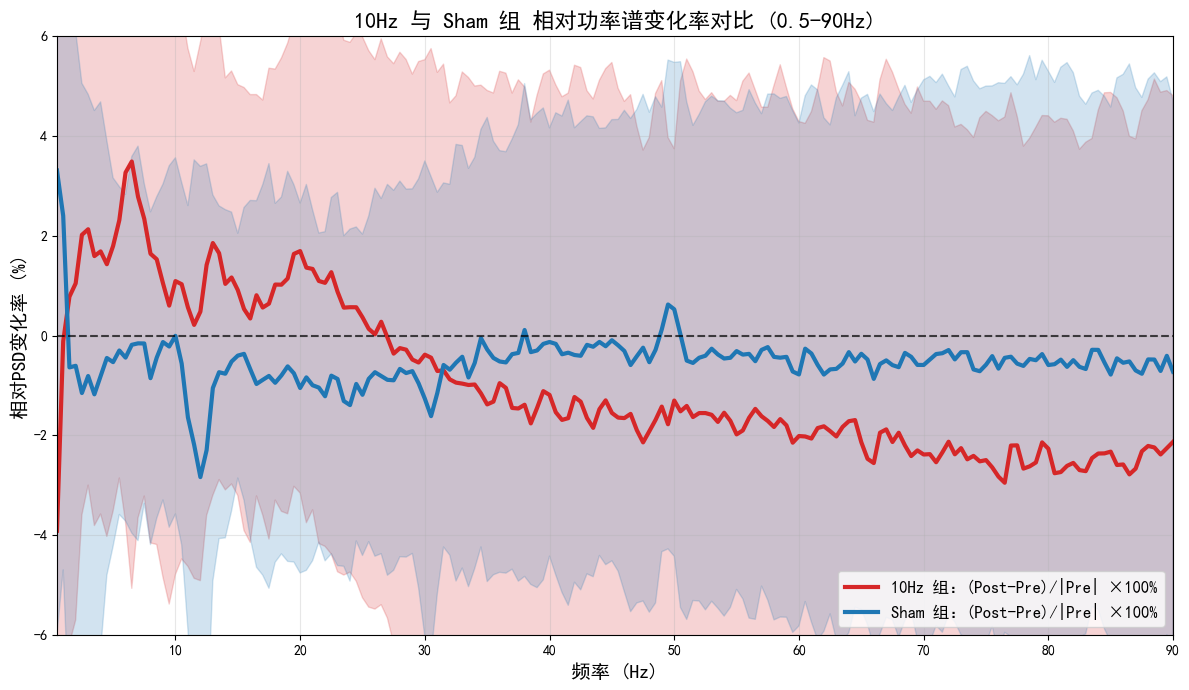

In [ ]:
# Visualization: (Post-Pre)/|Pre| ×100% Percentage, Y-axis range -6 ~ 6

# Define extraction function (average across factors + channels)
def extract_subject_psd(data):
    return np.mean(data, axis=(1, 2))  # (subject, freq)

# ===================== 1. Load Data =====================
file_10hz = r'D:\山东第一医科大学\数据\Task\八因子\PSD\10hz_relative_psd_power.mat'
mat_10hz = sio.loadmat(file_10hz)
power_10hz = mat_10hz['psd_full']

file_sham = r'D:\山东第一医科大学\数据\Task\八因子\PSD\sham_relative_psd_power.mat'
mat_sham = sio.loadmat(file_sham)
power_sham = mat_sham['psd_full']

# ===================== 2. Frequency Axis =====================
n_freq = power_10hz.shape[-1]
freq = np.arange(0.5, 0.5 + n_freq * 0.5, 0.5)

# ===================== 3. Extract Data =====================
# 10Hz Group
pre_10hz = extract_subject_psd(power_10hz[0, 1, :])
post_10hz = extract_subject_psd(power_10hz[1, 1, :])

# Sham Group
pre_sham = extract_subject_psd(power_sham[0, 1, :])
post_sham = extract_subject_psd(power_sham[1, 1, :])

# ===================== 4. Core Calculation =====================
eps = 1e-8
diff_ratio_10hz = (post_10hz - pre_10hz) / (np.abs(pre_10hz) + eps)
diff_ratio_sham = (post_sham - pre_sham) / (np.abs(pre_sham) + eps)

# ===================== 5. Convert to Percentage ×100 =====================
diff_ratio_10hz *= 100
diff_ratio_sham *= 100

# ===================== 6. Mean + Standard Deviation =====================
mean_ratio_10hz = np.mean(diff_ratio_10hz, axis=0)
std_ratio_10hz = np.std(diff_ratio_10hz, axis=0)

mean_ratio_sham = np.mean(diff_ratio_sham, axis=0)
std_ratio_sham = np.std(diff_ratio_sham, axis=0)

# ===================== 7. Plotting =====================
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(12, 7))

color_10hz = '#d62728'
color_sham = '#1f77b4'

# 10Hz Group
ax.plot(freq, mean_ratio_10hz, linewidth=3, color=color_10hz, label='10Hz Group: (Post-Pre)/|Pre| ×100%')
ax.fill_between(freq, mean_ratio_10hz-std_ratio_10hz, mean_ratio_10hz+std_ratio_10hz, color=color_10hz, alpha=0.2)

# Sham Group
ax.plot(freq, mean_ratio_sham, linewidth=3, color=color_sham, label='Sham Group: (Post-Pre)/|Pre| ×100%')
ax.fill_between(freq, mean_ratio_sham-std_ratio_sham, mean_ratio_sham+std_ratio_sham, color=color_sham, alpha=0.2)

# 0 Reference Line
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# ===================== Axis Settings =====================
ax.set_xlabel('Frequency (Hz)', fontsize=14)
ax.set_ylabel('Relative PSD Change Rate (%)', fontsize=14)
ax.set_title('Comparison of Relative Power Spectrum Change Rate between 10Hz and Sham Groups (0.5-90Hz)', fontsize=16, weight='bold')

ax.set_xlim(0.5, 90)
ax.set_ylim(-6, 6)  # Fixed Y-axis range -6 ~ 6

ax.grid(alpha=0.3)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()